In [ ]:
import pandas as pd
import numpy as np
import scipy as st
import geopandas as gp
import matplotlib.pyplot as plt
import seaborn as sns
import dotenv
import os
from shapely.geometry import point
dotenv.load_dotenv()

True

In [3]:
DIR = os.getenv("PROJECT_DIR")
df = pd.read_csv(DIR+"/data/cleaned/cleaned_nyc_311_dataset.csv")

In [4]:
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,...,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,resolution_time
0,56416396,2023-01-01 00:00:00,2023-01-03 14:56:48,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Restaurant/Bar/Deli/Bakery,11379.0,84-46 ELIOT AVENUE,...,QUEENS,1019280.0,204397.0,ONLINE,Unspecified,QUEENS,40.727630,-73.873614,"{'type': 'Point', 'coordinates': [-73.87361356...",2 days 14:56:48
1,56417527,2023-01-01 00:00:09,2023-01-01 00:36:06,NYPD,New York City Police Department,Illegal Fireworks,NaN,Street/Sidewalk,11218.0,AVENUE C,...,BROOKLYN,991565.0,172780.0,ONLINE,Unspecified,BROOKLYN,40.640915,-73.973642,"{'type': 'Point', 'coordinates': [-73.97364216...",0 days 00:35:57
2,56416252,2023-01-01 00:00:42,2023-01-01 17:34:15,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10453.0,1871 SEDGWICK AVENUE,...,BRONX,1007015.0,250368.0,ONLINE,Unspecified,BRONX,40.853848,-73.917709,"{'type': 'Point', 'coordinates': [-73.91770920...",0 days 17:33:33
3,56418795,2023-01-01 00:00:45,2023-01-01 01:24:10,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,10001.0,15 HUDSON BOULEVARD,...,MANHATTAN,984043.0,214298.0,MOBILE,Unspecified,MANHATTAN,40.754875,-74.000747,"{'type': 'Point', 'coordinates': [-74.00074715...",0 days 01:23:25
4,56418136,2023-01-01 00:00:46,2023-01-01 01:01:43,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11234.0,1621 EAST 51 STREET,...,BROOKLYN,1004782.0,165410.0,ONLINE,Unspecified,BROOKLYN,40.620665,-73.926040,"{'type': 'Point', 'coordinates': [-73.92604033...",0 days 01:00:57


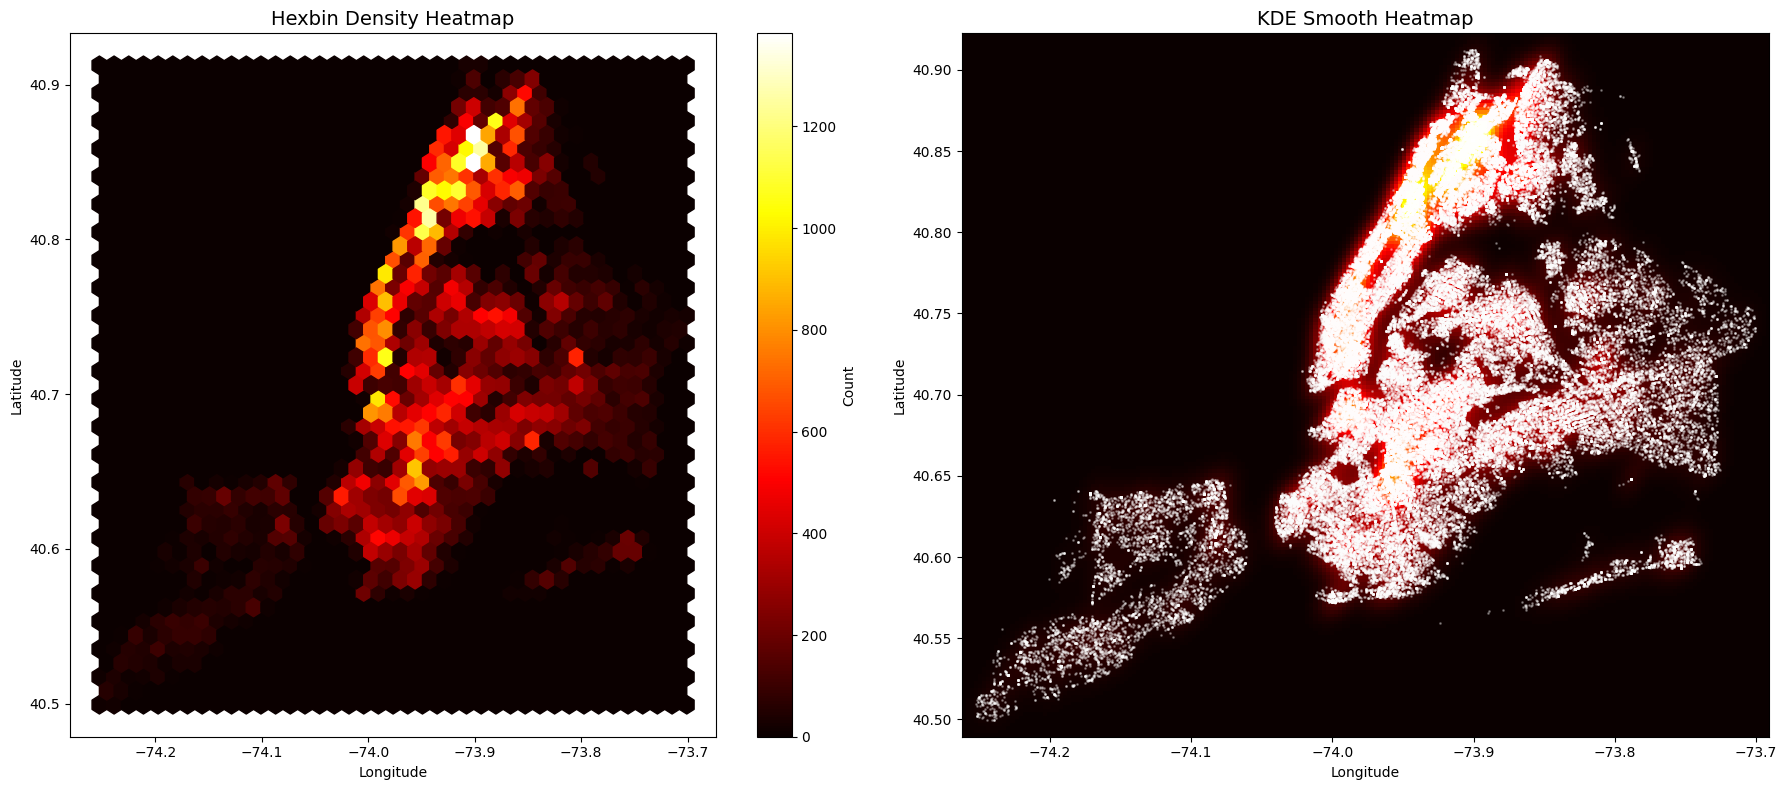

In [ ]:
geometry = gp.points_from_xy(df['longitude'],df['latitude'])
gdf = gp.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
fig, axes = plt.subplots(1,2,figsize = (18,8))
ax1 = axes[0]
hb = ax1.hexbin(
    gdf['longitude'],
    gdf['latitude'],
    gridsize = 40,
    cmap = 'hot'
)
ax1.set_title('Hexbin Density Heatmap', fontsize=14)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.colorbar(hb, ax=ax1, label='Count')
ax2 = axes[1]
x = gdf['longitude'].values
y = gdf['latitude'].values
xy = np.vstack([x,y])
kde = st.stats.gaussian_kde(xy,bw_method=0.1)
xmin, xmax = x.min() - 0.01, x.max() + 0.01
ymin, ymax = y.min() - 0.01, y.max() + 0.01
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
density = np.reshape(kde(positions), xx.shape)
 
ax2.imshow(
    np.rot90(density),
    cmap='hot',
    extent=[xmin, xmax, ymin, ymax],
    aspect='auto'
)
ax2.scatter(x, y, s=1, c='white', alpha=0.3)
ax2.set_title('KDE Smooth Heatmap', fontsize=14)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
 
plt.tight_layout()
plt.savefig('park_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

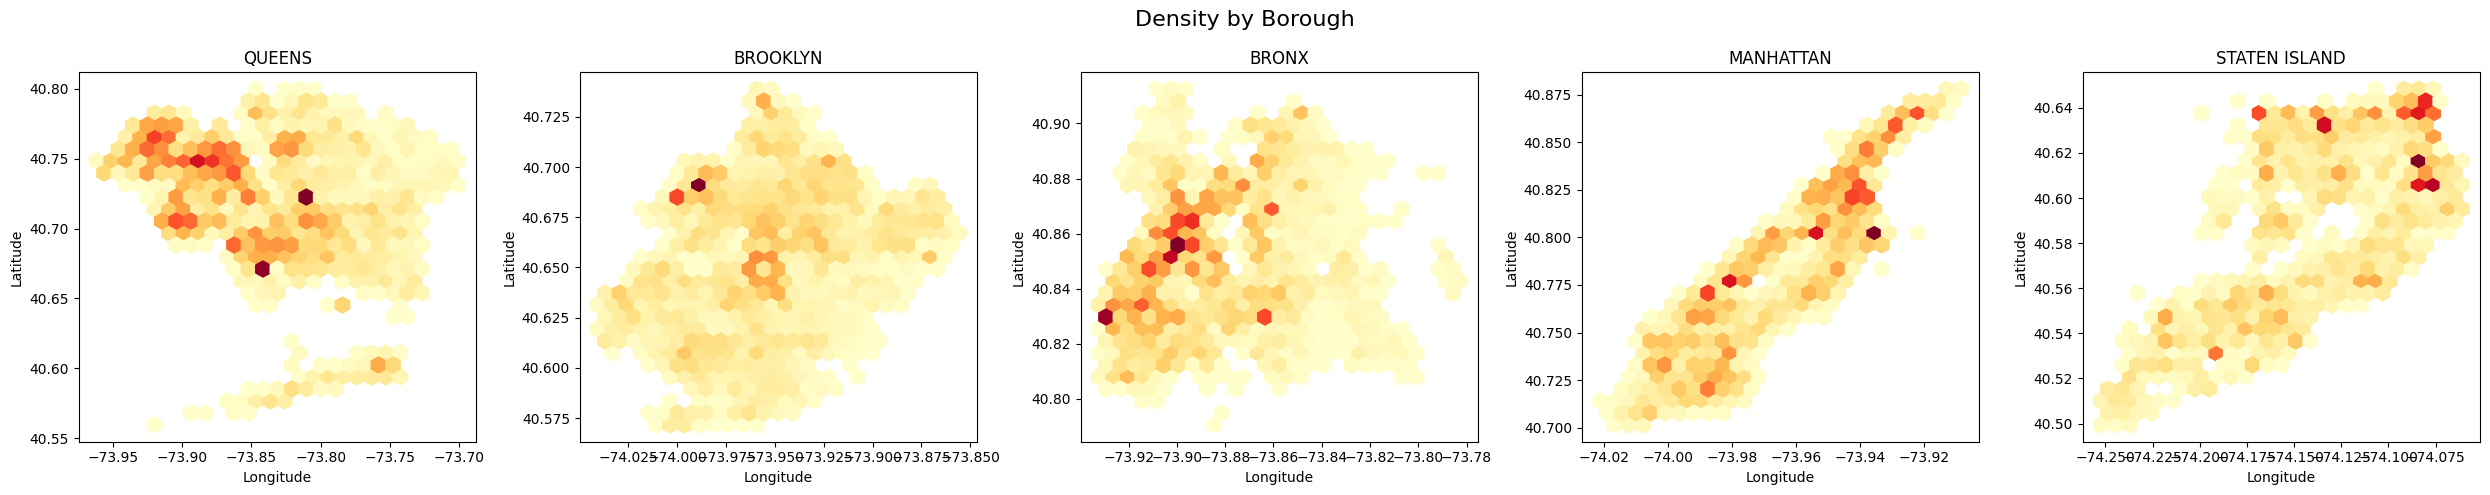

In [19]:
boroughs = gdf['park_borough'].dropna().unique()
n = len(boroughs)
 
if n > 0:
    fig2, axes2 = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes2 = [axes2]
 
    for ax, borough in zip(axes2, boroughs):
        subset = gdf[gdf['park_borough'] == borough]
        ax.hexbin(
            subset['longitude'],
            subset['latitude'],
            gridsize=25,
            cmap='YlOrRd',
            mincnt=1
        )
        ax.set_title(borough, fontsize=12)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
 
    plt.suptitle('Density by Borough', fontsize=16)
    plt.tight_layout()
    plt.savefig('park_heatmap_by_borough.png', dpi=150, bbox_inches='tight')
    plt.show()